In [14]:
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

class H5Dataset(Dataset):
    def __init__(self, path, x_key="X_train", y_key="Y_train"):
        with h5py.File(path, "r") as f:
            # Normalise les pixels uint8 [0,255] → float [0,1]
            self.X = torch.tensor(f[x_key][:], dtype=torch.float32) / 255.0
            # Aplatit (1000,1) → (1000,) pour BCE
            self.y = torch.tensor(f[y_key][:], dtype=torch.float32).squeeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        # Aplatit l'image 64x64 → 4096 pour le MLP
        return self.X[idx].view(-1), self.y[idx]


train_path = "/content/drive/MyDrive/dataset/trainset (1).hdf5"
test_path  = "/content/drive/MyDrive/dataset/testset (1).hdf5"

train_ds = H5Dataset(train_path)
test_ds  = H5Dataset(test_path, x_key="X_test", y_key="Y_test")  # adapte si les clés diffèrent

print(f"Train : {len(train_ds)} échantillons, X shape : {train_ds.X.shape}")
print(f"Test  : {len(test_ds)} échantillons")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)


Train : 1000 échantillons, X shape : torch.Size([1000, 64, 64])
Test  : 200 échantillons


Epoch 001 | Train Loss: 0.7274 | Train Acc: 52.90% | Test Loss: 0.8176 | Test Acc: 58.00%
Epoch 002 | Train Loss: 0.6624 | Train Acc: 63.40% | Test Loss: 0.8388 | Test Acc: 52.50%
Epoch 003 | Train Loss: 0.6120 | Train Acc: 66.70% | Test Loss: 0.7561 | Test Acc: 59.50%
Epoch 004 | Train Loss: 0.5476 | Train Acc: 71.30% | Test Loss: 0.7462 | Test Acc: 58.50%
Epoch 005 | Train Loss: 0.5009 | Train Acc: 75.50% | Test Loss: 0.9375 | Test Acc: 56.00%
Epoch 006 | Train Loss: 0.4803 | Train Acc: 78.80% | Test Loss: 0.9864 | Test Acc: 51.50%
Epoch 007 | Train Loss: 0.4333 | Train Acc: 81.90% | Test Loss: 1.0631 | Test Acc: 53.00%
Epoch 008 | Train Loss: 0.4109 | Train Acc: 79.70% | Test Loss: 0.8901 | Test Acc: 54.00%
Epoch 009 | Train Loss: 0.3310 | Train Acc: 85.10% | Test Loss: 0.9428 | Test Acc: 58.00%
Epoch 010 | Train Loss: 0.2751 | Train Acc: 89.10% | Test Loss: 1.0343 | Test Acc: 58.00%
Epoch 011 | Train Loss: 0.2256 | Train Acc: 91.40% | Test Loss: 1.0140 | Test Acc: 56.50%
Epoch 012 

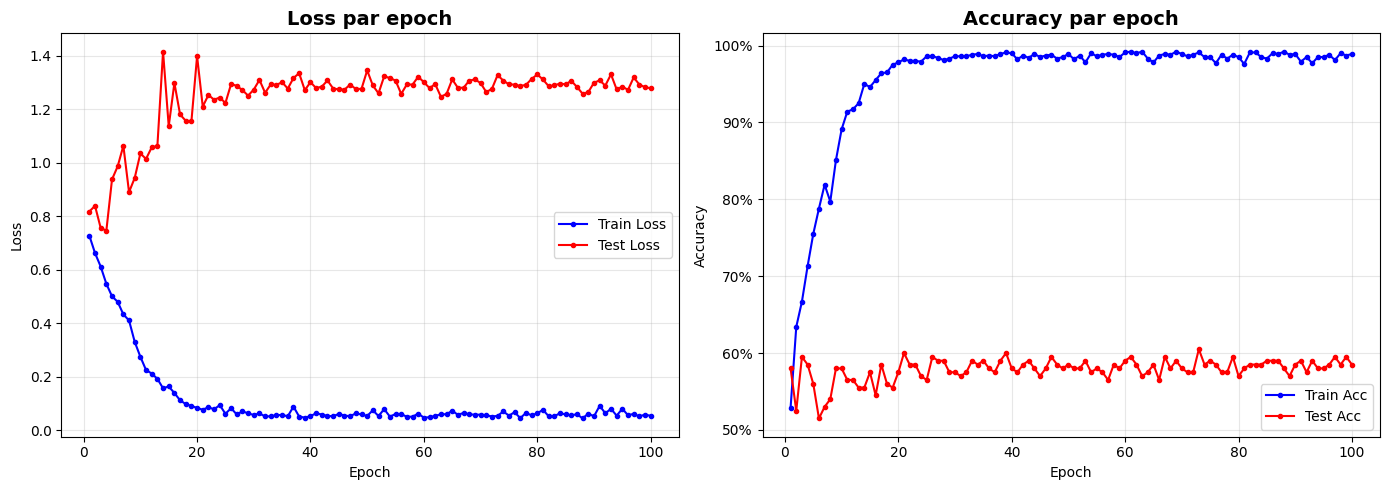

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

class Mlp(nn.Module):
    def __init__(self, n_input, n_hidden, n_out, dropout):
        super().__init__()
        self.w1  = nn.Linear(n_input, n_hidden)
        self.bn1 = nn.BatchNorm1d(n_hidden)
        self.w2  = nn.Linear(n_hidden, n_hidden)
        self.bn2 = nn.BatchNorm1d(n_hidden)
        self.drop = nn.Dropout(dropout)
        self.out = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        x = self.drop(F.relu(self.bn1(self.w1(x))))
        x = self.drop(F.relu(self.bn2(self.w2(x))))
        return self.out(x)

model     = Mlp(n_input=4096, n_hidden=512, n_out=1, dropout=0.4)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch).squeeze(1)
            total_loss += criterion(preds, y_batch).item()
            predicted = (torch.sigmoid(preds) >= 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total += len(y_batch)
    return total_loss / len(loader), correct / total

# ✅ Boucle unique propre
for epoch in range(100):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch).squeeze(1)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        predicted = (torch.sigmoid(preds) >= 0.5).float()
        correct   += (predicted == y_batch).sum().item()
        total     += len(y_batch)

    train_loss /= len(train_loader)
    train_acc   = correct / total
    test_loss, test_acc = evaluate(test_loader)
    scheduler.step(test_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}")

# Visualisation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)

ax1.plot(ep, history["train_loss"], "b-o", label="Train Loss", markersize=3)
ax1.plot(ep, history["test_loss"],  "r-o", label="Test Loss",  markersize=3)
ax1.set_title("Loss par epoch", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history["train_acc"], "b-o", label="Train Acc", markersize=3)
ax2.plot(ep, history["test_acc"],  "r-o", label="Test Acc",  markersize=3)
ax2.set_title("Accuracy par epoch", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


### CNN 


Shape X: torch.Size([1000, 1, 64, 64])
Paramètres : 2,190,785
Epoch 001 | Train Loss: 1.0192 | Train Acc: 53.70% | Test Loss: 0.6721 | Test Acc: 54.50%
Epoch 002 | Train Loss: 0.6595 | Train Acc: 60.80% | Test Loss: 0.7130 | Test Acc: 56.00%
Epoch 003 | Train Loss: 0.6296 | Train Acc: 63.70% | Test Loss: 0.7244 | Test Acc: 60.50%
Epoch 004 | Train Loss: 0.5931 | Train Acc: 67.50% | Test Loss: 0.7334 | Test Acc: 62.50%
Epoch 005 | Train Loss: 0.5868 | Train Acc: 67.20% | Test Loss: 0.7580 | Test Acc: 63.00%
Epoch 006 | Train Loss: 0.5299 | Train Acc: 73.30% | Test Loss: 0.7689 | Test Acc: 70.00%
Epoch 007 | Train Loss: 0.5076 | Train Acc: 76.50% | Test Loss: 0.8311 | Test Acc: 62.50%
Epoch 008 | Train Loss: 0.4493 | Train Acc: 78.10% | Test Loss: 0.7205 | Test Acc: 67.00%
Epoch 009 | Train Loss: 0.4125 | Train Acc: 80.90% | Test Loss: 0.6523 | Test Acc: 70.00%
Epoch 010 | Train Loss: 0.3363 | Train Acc: 86.10% | Test Loss: 0.6182 | Test Acc: 75.00%
Epoch 011 | Train Loss: 0.3142 | Train

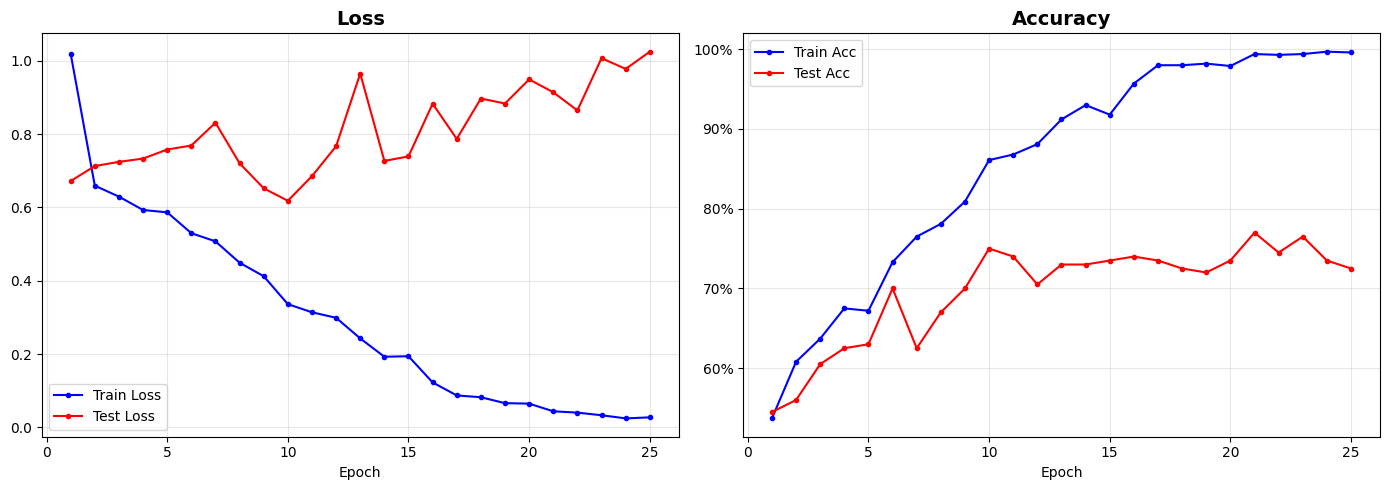

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import h5py
import torch
from torch.utils.data import Dataset, DataLoader

class H5Dataset(Dataset):
    def __init__(self, path, x_key="X_train", y_key="Y_train"):
        with h5py.File(path, "r") as f:
            # (N, 64, 64) → (N, 1, 64, 64) : ajoute le canal
            self.X = torch.tensor(f[x_key][:], dtype=torch.float32).unsqueeze(1) / 255.0
            self.y = torch.tensor(f[y_key][:], dtype=torch.float32).squeeze(1)

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]   # ← plus de .view(-1) !

train_path = "/content/drive/MyDrive/dataset/trainset (1).hdf5"
test_path  = "/content/drive/MyDrive/dataset/testset (1).hdf5"

train_ds = H5Dataset(train_path, x_key="X_train", y_key="Y_train")
test_ds  = H5Dataset(test_path,  x_key="X_test",  y_key="Y_test")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

# Vérification
print(f"Shape X: {train_ds.X.shape}")   # doit afficher torch.Size([1000, 1, 64, 64])

class CNN(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),


            nn.Conv2d(32,64, kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2), 
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),
            nn.Linear(128*8*8,256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)
model = CNN(dropout=0.4)
total_params = sum(p.numel() for p in model.parameters())
print(f"Paramètres : {total_params:,}")  # ~1.3M, bien moins que le MLP !
# ── 3. Entraînement ─────────────────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)
history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_test_loss  = float('inf')
patience_counter = 0
PATIENCE = 15
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            preds = model(X_batch).squeeze(1)
            total_loss += criterion(preds, y_batch).item()
            predicted = (torch.sigmoid(preds) >= 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total   += len(y_batch)
    return total_loss / len(loader), correct / total
for epoch in range(100):
    model.train()
    train_loss, correct, total = 0, 0, 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        preds = model(X_batch).squeeze(1)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        predicted = (torch.sigmoid(preds) >= 0.5).float()
        correct   += (predicted == y_batch).sum().item()
        total     += len(y_batch)
    train_loss /= len(train_loader)
    train_acc   = correct / total
    test_loss, test_acc = evaluate(test_loader)
    scheduler.step(test_loss)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)
    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}")
    # Early stopping
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), "best_cnn.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⛔ Early stopping à l'epoch {epoch+1}")
            break
model.load_state_dict(torch.load("best_cnn.pt"))
print(f"\n✅ Meilleur modèle rechargé | Test Loss: {best_test_loss:.4f}")
# ── 4. Visualisation ────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)
ax1.plot(ep, history["train_loss"], "b-o", label="Train Loss", markersize=3)
ax1.plot(ep, history["test_loss"],  "r-o", label="Test Loss",  markersize=3)
ax1.set_title("Loss", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)
ax2.plot(ep, history["train_acc"], "b-o", label="Train Acc", markersize=3)
ax2.plot(ep, history["test_acc"],  "r-o", label="Test Acc",  markersize=3)
ax2.set_title("Accuracy", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(); ax2.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


### VIT

Device : cpu
✅ ViT défini !


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 001 | Train Loss: 0.7160 | Train Acc: 50.60% | Test Loss: 0.6969 | Test Acc: 50.00%
Epoch 002 | Train Loss: 0.7105 | Train Acc: 51.20% | Test Loss: 0.6986 | Test Acc: 50.00%
Epoch 003 | Train Loss: 0.7059 | Train Acc: 51.50% | Test Loss: 0.6945 | Test Acc: 50.00%
Epoch 004 | Train Loss: 0.7059 | Train Acc: 48.30% | Test Loss: 0.6972 | Test Acc: 50.00%
Epoch 005 | Train Loss: 0.7006 | Train Acc: 48.30% | Test Loss: 0.6947 | Test Acc: 50.00%
Epoch 006 | Train Loss: 0.6943 | Train Acc: 50.50% | Test Loss: 0.6910 | Test Acc: 52.50%
Epoch 007 | Train Loss: 0.6922 | Train Acc: 52.30% | Test Loss: 0.6894 | Test Acc: 52.50%
Epoch 008 | Train Loss: 0.6995 | Train Acc: 50.40% | Test Loss: 0.6915 | Test Acc: 50.50%
Epoch 009 | Train Loss: 0.6935 | Train Acc: 52.60% | Test Loss: 0.6926 | Test Acc: 51.50%
Epoch 010 | Train Loss: 0.6961 | Train Acc: 52.00% | Test Loss: 0.7038 | Test Acc: 50.00%
Epoch 011 | Train Loss: 0.6859 | Train Acc: 55.00% | Test Loss: 0.7267 | Test Acc: 50.00%
Epoch 012 

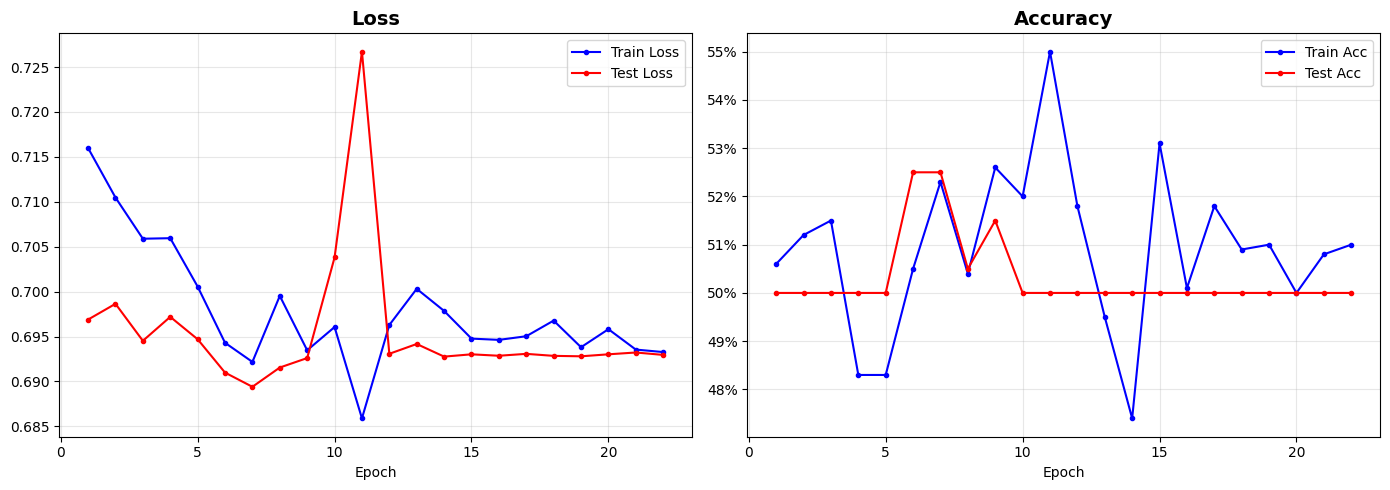

In [5]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# ── Device ──────────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

# ── Dataset ─────────────────────────────────────────────────────────────────
class H5Dataset(Dataset):
    def __init__(self, path, x_key="X_train", y_key="Y_train"):
        with h5py.File(path, "r") as f:
            self.X = torch.tensor(f[x_key][:], dtype=torch.float32).unsqueeze(1) / 255.0
            self.y = torch.tensor(f[y_key][:], dtype=torch.float32).squeeze(1)

    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# Fichiers locaux (plus besoin de Drive !)
train_ds = H5Dataset("/content/drive/MyDrive/dataset/trainset (1).hdf5", x_key="X_train", y_key="Y_train")
test_ds  = H5Dataset("/content/drive/MyDrive/dataset/testset (1).hdf5",  x_key="X_test",  y_key="Y_test")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  pin_memory=True,num_workers=4)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, pin_memory=True,num_workers=4)

class PatchEmbedding(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1, embed_dim=128):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim,
                              kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)       # (B, embed_dim, 8, 8)
        x = x.flatten(2)       # (B, embed_dim, 64)
        x = x.transpose(1, 2)  # (B, 64, embed_dim)
        return x
class ViT(nn.Module):
    def __init__(self, img_size=64, patch_size=8, in_channels=1,
                 embed_dim=128, n_heads=4, n_layers=4, dropout=0.4):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        n_patches = (img_size // patch_size) ** 2
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, embed_dim))
        self.dropout   = nn.Dropout(dropout)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads,
            dim_feedforward=256, dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, 1)
    def forward(self, x):
        B = x.shape[0]
        x   = self.patch_embed(x)
        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = self.dropout(x + self.pos_embed)
        x   = self.transformer(x)
        x   = self.norm(x[:, 0])
        return self.head(x)
print("✅ ViT défini !")
# ── Modèle sur GPU ───────────────────────────────────────────────────────────
model     = ViT().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
best_test_loss   = float('inf')
patience_counter = 0
PATIENCE = 15

# ── Evaluate ─────────────────────────────────────────────────────────────────
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds   = model(X_batch).squeeze(1)
            total_loss += criterion(preds, y_batch).item()
            predicted   = (torch.sigmoid(preds) >= 0.5).float()
            correct += (predicted == y_batch).sum().item()
            total   += len(y_batch)
    return total_loss / len(loader), correct / total

# ── Training loop ─────────────────────────────────────────────────────────────
for epoch in range(100):
    model.train()
    train_loss, correct, total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)   # ← GPU
        y_batch = y_batch.to(device)   # ← GPU

        optimizer.zero_grad()
        preds = model(X_batch).squeeze(1)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        predicted   = (torch.sigmoid(preds) >= 0.5).float()
        correct    += (predicted == y_batch).sum().item()
        total      += len(y_batch)

    train_loss /= len(train_loader)
    train_acc   = correct / total
    test_loss, test_acc = evaluate(test_loader)
    scheduler.step(test_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2%} | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2%}")

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save(model.state_dict(), "best_vit.pt")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⛔ Early stopping à l'epoch {epoch+1}")
            break

model.load_state_dict(torch.load("best_vit.pt"))
print(f"\n✅ Meilleur modèle | Test Loss: {best_test_loss:.4f}")

# ── Visualisation ─────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ep = range(1, len(history["train_loss"]) + 1)

ax1.plot(ep, history["train_loss"], "b-o", label="Train Loss", markersize=3)
ax1.plot(ep, history["test_loss"],  "r-o", label="Test Loss",  markersize=3)
ax1.set_title("Loss", fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history["train_acc"], "b-o", label="Train Acc", markersize=3)
ax2.plot(ep, history["test_acc"],  "r-o", label="Test Acc",  markersize=3)
ax2.set_title("Accuracy", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


In [7]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found
